<a href="https://colab.research.google.com/github/kiblernehemiah01-art/FEMA-Project/blob/main/Copy_of_Nehemiah_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
                      # INFO 450_HW

                      # December 08, 2025

1: Load and Explore Data

In [ ]:
# Import libraries
import time
import urllib.request
import pandas as pd

# URL to download the dataset
url = "https://storage.googleapis.com/info_450/IndividualAssistanceHousingRegistrantsLargeDisasters%20(1).csv"
filename = "fema_disaster_data.csv"

# Measure the time taken to download the file
print(f"Downloading {filename}...")
start = time.time()
urllib.request.urlretrieve(url, filename)
print(f"Done in {time.time() - start:.2f} seconds.")

# Load the dataset into a DataFrame
df = pd.read_csv(filename, low_memory=False)

# Display the first few rows to ensure it's loaded properly
df.head()



Done in 34.25 seconds.


,disasterNumber,damagedCity,damagedStateAbbreviation,damagedZipCode,householdComposition,grossIncome,specialNeeds,ownRent,residenceType,homeOwnersInsurance,...,rentalAssistanceEndDate,rentalResourceCity,rentalResourceStateAbbreviation,rentalResourceZipCode,primaryResidence,personalPropertyEligible,ppfvl,censusBlockId,id,censusYear
0,4332,HOUSTON,TX,77036.0,1,1800.0,1,Renter,Apartment,0,...,NaN,NaN,NaN,NaN,1.0,0,NaN,4.820143e+14,d214ed1e-951e-484b-b014-2a885a7ea234,2010.0
1,4337,SARASOTA,FL,34238.0,1,NaN,0,Renter,Condo,0,...,NaN,NaN,NaN,NaN,1.0,0,NaN,1.211500e+14,e7b10c4f-adec-4a58-a4fc-85b5a20dfa4c,2010.0
2,4337,KISSIMMEE,FL,34758.0,1,28000.0,0,Renter,House/Duplex,0,...,NaN,NaN,NaN,NaN,1.0,0,0.00,1.209704e+14,0832cc95-c445-4429-956c-e2d1864d37ac,2010.0
3,4339,ARECIBO,PR,612.0,2,2100.0,0,Owner,House/Duplex,0,...,NaN,NaN,NaN,NaN,1.0,0,199.99,7.201330e+14,63bc856a-5cfa-44c8-96e1-f1866735cf94,2010.0
4,4559,SULPHUR,LA,70663.0,4,55000.0,0,Renter,Apartment,0,...,NaN,NaN,NaN,NaN,1.0,0,NaN,2.201900e+14,ce6f1140-3777-41d8-8da0-f7f4891b2228,2020.0


N/A

2: Select Relevant Columns and Handle Missing Values

In [ ]:

cols = [
    "disasterNumber",
    "damagedCity",
    "damagedStateAbbreviation",
    "residenceType",
    "grossIncome",
    "tsaEligible",
    "repairAmount",
    "destroyed",
    "waterLevel",
    "specialNeeds"
]

df = df[cols].copy()

# Basic cleaning
str_cols = ["damagedCity", "damagedStateAbbreviation", "residenceType", "grossIncome"]
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()

# Handle missing values
df["damagedCity"] = df["damagedCity"].replace(["", "nan", "NaN", "None"], "Unknown")
df["residenceType"] = df["residenceType"].replace(["", "nan", "NaN", "None"], "Unknown")
df["grossIncome"] = df["grossIncome"].replace(["", "nan", "NaN", "None"], "Unknown")

df["tsaEligible"] = pd.to_numeric(df["tsaEligible"], errors="coerce")
df = df[df["tsaEligible"].isin([0, 1])]

df["repairAmount"] = pd.to_numeric(df["repairAmount"], errors="coerce")
df["repairAmount"] = df["repairAmount"].fillna(0)  # Assume missing repair amounts are 0

df["waterLevel"] = pd.to_numeric(df["waterLevel"], errors="coerce")
df["waterLevel"] = df["waterLevel"].fillna(0)  # Assume missing water levels are 0

# Check for remaining missing values
print("Remaining missing values:")
print(df.isna().sum())

Remaining missing values:
disasterNumber              0
damagedCity                 0
damagedStateAbbreviation    0
residenceType               0
grossIncome                 0
tsaEligible                 0
repairAmount                0
destroyed                   0
waterLevel                  0
specialNeeds                0
dtype: int64


N/A

3: EDA

In [ ]:
# 3: EDA – TSA by residence type and state

ct_res_state = pd.crosstab(
    [df["damagedStateAbbreviation"], df["residenceType"]],
    df["tsaEligible"],
    normalize="index"
)

ct_res_state.rename(columns={0: "Not_TSA_Eligible", 1: "TSA_Eligible"}, inplace=True)
ct_res_state.head(10)



tsaEligible                                        Not_TSA_Eligible  \
damagedStateAbbreviation residenceType                                
AL                       Apartment                         1.000000   
CA                       Apartment                         1.000000   
                         House/Duplex                      0.000000   
FL                       Apartment                         0.636970   
                         Assisted Living Facility          0.714087   
                         Boat                              0.569449   
                         College Dorm                      0.874525   
                         Condo                             0.626629   
                         Correctional Facility             0.666667   
                         House/Duplex                      0.696277   

tsaEligible                                        TSA_Eligible  
damagedStateAbbreviation residenceType                           
AL                       Apartment                     0.000000  
CA                       Apartment                     0.000000  
                         House/Duplex                  1.000000  
FL                       Apartment                     0.363030  
                         Assisted Living Facility      0.285913  
                         Boat                          0.430551  
                         College Dorm                  0.125475  
                         Condo                         0.373371  
                         Correctional Facility         0.333333  
                         House/Duplex                  0.303723

N/A

4: Average Repair Amount by State

In [ ]:

avg_repair_by_state = (
    df.groupby("damagedStateAbbreviation", as_index=False)["repairAmount"]
      .mean()
      .rename(columns={"repairAmount": "avgRepairAmount"})
      .sort_values("avgRepairAmount", ascending=False)
)

avg_repair_by_state.head(10)


,damagedStateAbbreviation,avgRepairAmount
15,TX,737.836743
9,NC,500.744284
13,PR,489.311442
4,LA,437.038732
2,FL,90.599423
0,AL,0.000000
1,CA,0.000000
6,MI,0.000000
5,MD,0.000000
3,GA,0.000000


N/A

5: Part.1 Histogram

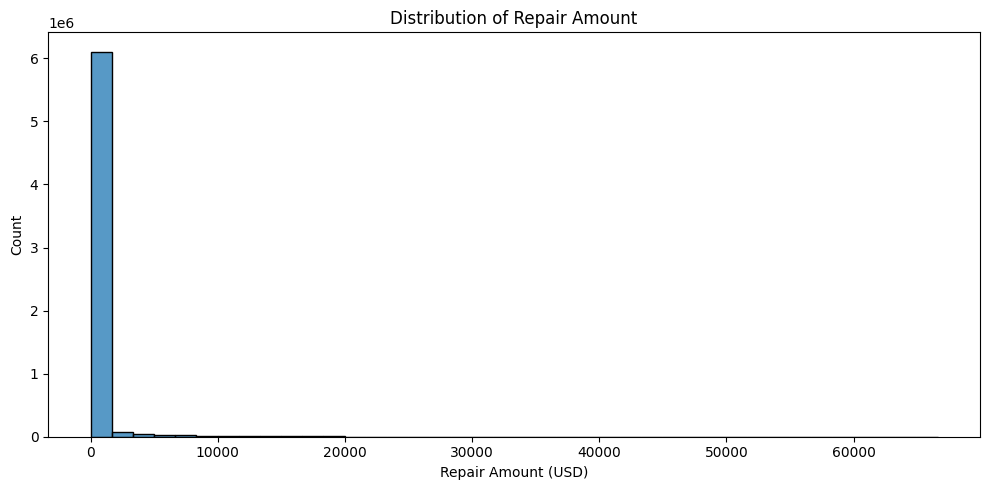

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df["repairAmount"].dropna(), bins=40, kde=False)
plt.xlabel("Repair Amount (USD)")
plt.ylabel("Count")
plt.title("Distribution of Repair Amount")
plt.tight_layout()
plt.show()



N/A

5: Part.2 Boxplot Repair by Residence Type

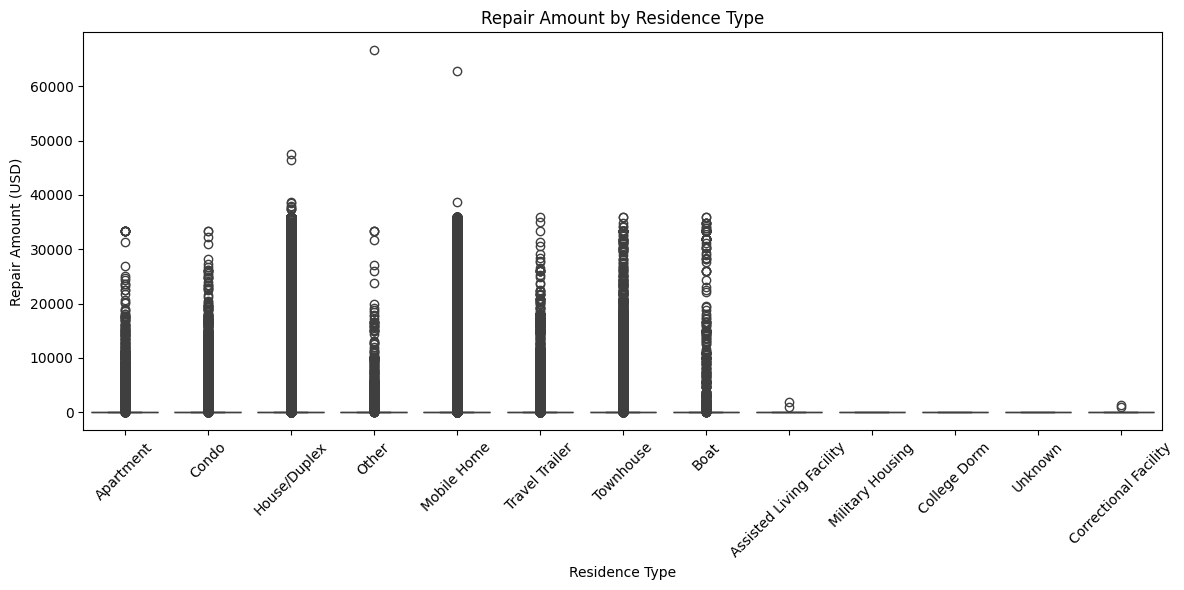

In [ ]:

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="residenceType", y="repairAmount")
plt.xticks(rotation=45)
plt.xlabel("Residence Type")
plt.ylabel("Repair Amount (USD)")
plt.title("Repair Amount by Residence Type")
plt.tight_layout()
plt.show()



N/A

5: Part.3 Boxplot Repair Amount by TSA

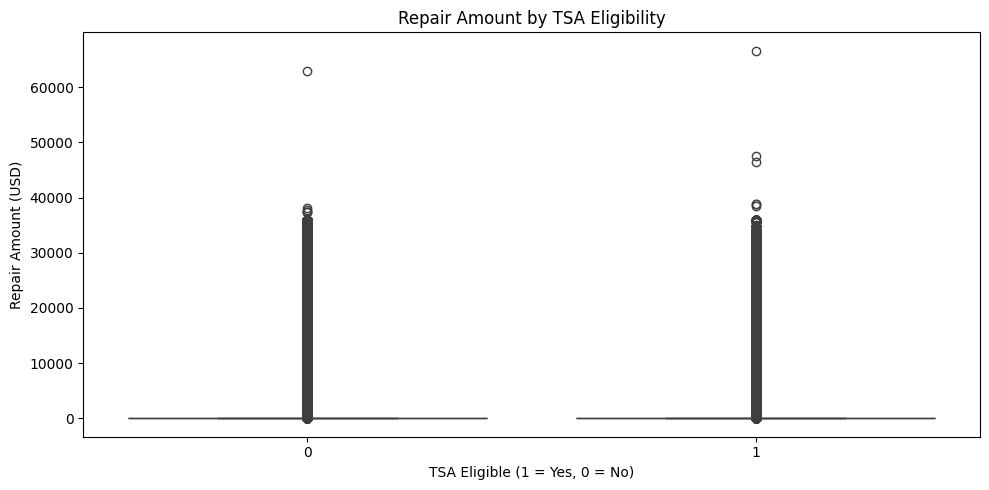

In [ ]:

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="tsaEligible", y="repairAmount")
plt.xlabel("TSA Eligible (1 = Yes, 0 = No)")
plt.ylabel("Repair Amount (USD)")
plt.title("Repair Amount by TSA Eligibility")
plt.tight_layout()
plt.show()



N/A

Load Data Again

In [ ]:
import pandas as pd

# Load the dataset (ensure the file path is correct)
df = pd.read_csv("fema_disaster_data.csv", low_memory=False)

# Display the first few rows of the dataframe to verify
df.head()

,disasterNumber,damagedCity,damagedStateAbbreviation,damagedZipCode,householdComposition,grossIncome,specialNeeds,ownRent,residenceType,homeOwnersInsurance,...,rentalAssistanceEndDate,rentalResourceCity,rentalResourceStateAbbreviation,rentalResourceZipCode,primaryResidence,personalPropertyEligible,ppfvl,censusBlockId,id,censusYear
0,4332,HOUSTON,TX,77036.0,1,1800.0,1,Renter,Apartment,0,...,NaN,NaN,NaN,NaN,1.0,0,NaN,4.820143e+14,d214ed1e-951e-484b-b014-2a885a7ea234,2010.0
1,4337,SARASOTA,FL,34238.0,1,NaN,0,Renter,Condo,0,...,NaN,NaN,NaN,NaN,1.0,0,NaN,1.211500e+14,e7b10c4f-adec-4a58-a4fc-85b5a20dfa4c,2010.0
2,4337,KISSIMMEE,FL,34758.0,1,28000.0,0,Renter,House/Duplex,0,...,NaN,NaN,NaN,NaN,1.0,0,0.00,1.209704e+14,0832cc95-c445-4429-956c-e2d1864d37ac,2010.0
3,4339,ARECIBO,PR,612.0,2,2100.0,0,Owner,House/Duplex,0,...,NaN,NaN,NaN,NaN,1.0,0,199.99,7.201330e+14,63bc856a-5cfa-44c8-96e1-f1866735cf94,2010.0
4,4559,SULPHUR,LA,70663.0,4,55000.0,0,Renter,Apartment,0,...,NaN,NaN,NaN,NaN,1.0,0,NaN,2.201900e+14,ce6f1140-3777-41d8-8da0-f7f4891b2228,2020.0


N/A

5: Part.4 TSA Eligibility Rate by Gross Income

In [ ]:

import plotly.express as px

# Ensure that grossIncome is numeric, convert invalid parsing to NaN
df["grossIncome"] = pd.to_numeric(df["grossIncome"], errors="coerce")

# Handle missing values in grossIncome (you can choose to fill or drop)
df["grossIncome"] = df["grossIncome"].fillna(0)  # Replace missing values with 0 (or use another strategy)

# Compute TSA eligibility rate by grossIncome category
tsa_by_income = (
    df.groupby("grossIncome")["tsaEligible"]
    .mean()
    .reset_index(name="tsaRate")
    .sort_values("tsaRate", ascending=False)  # Sort by eligibility rate
)

# Plot TSA eligibility rate by gross income category using Plotly
fig_income = px.bar(tsa_by_income, x="grossIncome", y="tsaRate", title="TSA Eligibility Rate by Gross Income")
fig_income.update_layout(
    xaxis_title="Gross Income Category",
    yaxis_title="TSA Eligibility Rate"
)
fig_income.show()  # Display the interactive bar plot



N/A

(Part II- Inferential Statistics) 5: Helper Function for 95% CI of Mean

In [ ]:
import numpy as np
import scipy.stats as stats

# Helper function for 95% Confidence Interval of Mean
def mean_confidence_interval(data, confidence=0.95):
    """
    Calculate the confidence interval for the mean of a dataset.

    Parameters:
    - data: The data (Series or array-like) for which the confidence interval is calculated.
    - confidence: The confidence level, default is 95%.

    Returns:
    - mean: The sample mean.
    - lower: The lower bound of the confidence interval.
    - upper: The upper bound of the confidence interval.
    - n: The sample size.
    """
    data = np.array(data.dropna())  # Drop missing values
    if len(data) == 0:
        return np.nan, np.nan, np.nan, 0  # Return NaN if the data is empty

    n = len(data)  # Sample size
    mean = np.mean(data)  # Mean of the sample
    sem = stats.sem(data)  # Standard error of the mean
    h = sem * stats.t.ppf((1 + confidence) / 2, n - 1)  # Margin of error
    return mean, mean - h, mean + h, n  # Return the mean, lower bound, upper bound, and sample size



N/A

5: Part.2 CI TSA-Eligible vs Not-Eligible

In [ ]:
# Extract repair amounts for TSA-Eligible and Non-TSA-Eligible households
tsa = df[df["tsaEligible"] == 1]["repairAmount"].dropna()  # TSA-Eligible
not_tsa = df[df["tsaEligible"] == 0]["repairAmount"].dropna()  # Non-TSA-Eligible

# Calculate confidence intervals for TSA-Eligible households
mean_tsa, lower_tsa, upper_tsa, n_tsa = mean_confidence_interval(tsa)
print("TSA-Eligible households:")
print(f"  n = {n_tsa}")
print(f"  Mean repairAmount = {mean_tsa:,.2f}")
print(f"  95% CI = [{lower_tsa:,.2f}, {upper_tsa:,.2f}]")

# Calculate confidence intervals for Non-TSA-Eligible households
mean_not, lower_not, upper_not, n_not = mean_confidence_interval(not_tsa)
print("\nNon-TSA-Eligible households:")
print(f"  n = {n_not}")
print(f"  Mean repairAmount = {mean_not:,.2f}")
print(f"  95% CI = [{lower_not:,.2f}, {upper_not:,.2f}]")


TSA-Eligible households:
  n = 238725
  Mean repairAmount = 5,951.65
  95% CI = [5,922.48, 5,980.81]

Non-TSA-Eligible households:
  n = 179020
  Mean repairAmount = 4,874.74
  95% CI = [4,848.15, 4,901.32]


N/A

5: Part.3 Two- Sample T-Test

In [ ]:
# Two-sample t-test (Welch’s t-test) to compare TSA-Eligible vs Non-TSA-Eligible households
tstat, pval = stats.ttest_ind(tsa, not_tsa, equal_var=False)  # Welch's t-test assumes unequal variance
print(f"\nTwo-sample t-test (Welch): t = {tstat:.3f}, p = {pval:.4g}")




Two-sample t-test (Welch): t = 53.487, p = 0


N/A

5: Part.4 CI Repair Amount by State

In [ ]:
# Comparison between two states (e.g., Texas and Louisiana)
state1 = "TX"
state2 = "LA"

# Extract repair amounts for Texas and Louisiana
s1 = df[df["damagedStateAbbreviation"] == state1]["repairAmount"].dropna()
s2 = df[df["damagedStateAbbreviation"] == state2]["repairAmount"].dropna()

# Calculate confidence intervals for each state
mean1, low1, up1, n1 = mean_confidence_interval(s1)
mean2, low2, up2, n2 = mean_confidence_interval(s2)

# Print results for both states
print(f"{state1}: n={n1}, mean={mean1:,.2f}, 95% CI=[{low1:,.2f}, {up1:,.2f}]")
print(f"{state2}: n={n2}, mean={mean2:,.2f}, 95% CI=[{low2:,.2f}, {up2:,.2f}]")

# Perform a two-sample t-test (Welch’s) for the two states
tstat_states, pval_states = stats.ttest_ind(s1, s2, equal_var=False)
print(f"\nTwo-sample t-test: t={tstat_states:.3f}, p={pval_states:.4g}")


TX: n=114555, mean=8,459.10, 95% CI=[8,411.81, 8,506.39]
LA: n=67124, mean=6,796.13, 95% CI=[6,745.13, 6,847.13]

Two-sample t-test: t=46.864, p=0


N/A

6: (Part III- Predictive Modeling)

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("fema_disaster_data.csv")  # Make sure this file exists in the working directory

# Alternatively, if the file path is different, use the full path
# df = pd.read_csv("/path/to/fema_disaster_data.csv")

try:
    # Print the first few rows of the dataframe
    print(df.head())

    # Print the data types of each column
    print(df.dtypes)

except Exception as e:
    # If an error occurs, print the error message
    print(f"Error: {e}")



   disasterNumber damagedCity damagedStateAbbreviation  damagedZipCode  \
0            4332     HOUSTON                       TX         77036.0   
1            4337    SARASOTA                       FL         34238.0   
2            4337   KISSIMMEE                       FL         34758.0   
3            4339     ARECIBO                       PR           612.0   
4            4559     SULPHUR                       LA         70663.0   

   householdComposition  grossIncome  specialNeeds ownRent residenceType  \
0                     1       1800.0             1  Renter     Apartment   
1                     1          NaN             0  Renter         Condo   
2                     1      28000.0             0  Renter  House/Duplex   
3                     2       2100.0             0   Owner  House/Duplex   
4                     4      55000.0             0  Renter     Apartment   

   homeOwnersInsurance  ...  rentalAssistanceEndDate  rentalResourceCity  \
0                    0

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Prepare the dataset for modeling
model_df = df.copy()
model_df = model_df.dropna(subset=["repairAmount"])  # Drop rows with missing repairAmount

# Select features for modeling
features = [
    "repairAmount",
    "grossIncome",
    "destroyed",
    "waterLevel",
    "residenceType",
    "damagedStateAbbreviation",
    "specialNeeds"
]

# Filter data for features and the target variable (tsaEligible)
model_df = model_df[features + ["tsaEligible"]].copy()

# Fill remaining missing values for features (you can fill or drop based on your strategy)
model_df["waterLevel"] = model_df["waterLevel"].fillna(0)
model_df["destroyed"] = model_df["destroyed"].astype("Int64").fillna(0)
model_df["specialNeeds"] = model_df["specialNeeds"].astype("Int64").fillna(0)

# Handle categorical features by filling with 'Unknown'
for col in ["grossIncome", "residenceType", "damagedStateAbbreviation"]:
    model_df[col] = model_df[col].fillna("Unknown")

# Split the data into features (X) and target (y)
X = model_df.drop("tsaEligible", axis=1)
y = model_df["tsaEligible"]


N/A

In [ ]:
# Import necessary libraries
import pandas as pd

# Load the dataset (ensure the file path is correct)
df = pd.read_csv("fema_disaster_data.csv")  # Ensure the correct path to the CSV file

# Display the first few rows of the dataframe to verify it has been loaded correctly
df.head()



,disasterNumber,damagedCity,damagedStateAbbreviation,damagedZipCode,householdComposition,grossIncome,specialNeeds,ownRent,residenceType,homeOwnersInsurance,...,rentalAssistanceEndDate,rentalResourceCity,rentalResourceStateAbbreviation,rentalResourceZipCode,primaryResidence,personalPropertyEligible,ppfvl,censusBlockId,id,censusYear
0,4332,HOUSTON,TX,77036.0,1,1800.0,1,Renter,Apartment,0,...,NaN,NaN,NaN,NaN,1.0,0,NaN,4.820143e+14,d214ed1e-951e-484b-b014-2a885a7ea234,2010.0
1,4337,SARASOTA,FL,34238.0,1,NaN,0,Renter,Condo,0,...,NaN,NaN,NaN,NaN,1.0,0,NaN,1.211500e+14,e7b10c4f-adec-4a58-a4fc-85b5a20dfa4c,2010.0
2,4337,KISSIMMEE,FL,34758.0,1,28000.0,0,Renter,House/Duplex,0,...,NaN,NaN,NaN,NaN,1.0,0,0.00,1.209704e+14,0832cc95-c445-4429-956c-e2d1864d37ac,2010.0
3,4339,ARECIBO,PR,612.0,2,2100.0,0,Owner,House/Duplex,0,...,NaN,NaN,NaN,NaN,1.0,0,199.99,7.201330e+14,63bc856a-5cfa-44c8-96e1-f1866735cf94,2010.0
4,4559,SULPHUR,LA,70663.0,4,55000.0,0,Renter,Apartment,0,...,NaN,NaN,NaN,NaN,1.0,0,NaN,2.201900e+14,ce6f1140-3777-41d8-8da0-f7f4891b2228,2020.0


6: Part.2 Encode Categorical Features

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Define the column transformer to apply OneHotEncoding to categorical variables
categorical_cols = ['residenceType', 'damagedStateAbbreviation']
numerical_cols = ['repairAmount', 'grossIncome', 'destroyed', 'waterLevel', 'specialNeeds']

# Apply OneHotEncoder to categorical columns and leave the numerical columns unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_cols),  # OneHotEncoder for categorical columns
        ('num', 'passthrough', numerical_cols)  # 'passthrough' for numerical columns
    ])

# Prepare the feature matrix (X) and the target vector (y)
X = model_df.drop('tsaEligible', axis=1)
y = model_df['tsaEligible']

# Transform the data
X_encoded = preprocessor.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")




NameError: name 'model_df' is not defined

N/A

Train Random Forest

In [ ]:
# Step 1: Select the target variable 'tsaEligible' and features 'X'
y = model_df["tsaEligible"]  # Target variable (TSA eligibility)
X = X_encoded  # Features (after encoding)

# Step 2: Split the data into training and testing sets (70% training, 30% testing)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,  # 30% for testing, 70% for training
    random_state=42,  # For reproducibility
    stratify=y  # Ensures balanced distribution of classes (TSA eligible vs not)
)

# Step 3: Train the Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

# Step 4: Evaluate the Decision Tree Model
y_pred_dt = dt_clf.predict(X_test)

print("Decision Tree Classifier Performance")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Step 5: Train the Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

# Step 6: Evaluate the Random Forest Model
y_pred_rf = rf_clf.predict(X_test)

print("\nRandom Forest Classifier Performance")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


NameError: name 'model_df' is not defined

N/A

Part 4: Streamlit Visual and Dashboard

In [ ]:
# We'll use a smaller subset for Streamlit if needed
streamlit_df = df_sample.copy()
streamlit_df.to_csv("fema_streamlit_data.csv", index=False)


N/A

Part IV - Streamlit App

In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="FEMA Disaster Relief Dashboard", layout="wide")

st.title("FEMA Disaster Relief Dashboard")
st.write("Authors: Your Name")

# Load and clean the data
df = pd.read_csv("IndividualAssistanceHousingRegistrantsLargeDisasters (2).csv")
df["repairAmount"] = pd.to_numeric(df["repairAmount"], errors="coerce")
df["tsaEligible"] = pd.to_numeric(df["tsaEligible"], errors="coerce")

# Sidebar filters
states = ["All"] + sorted(df["damagedStateAbbreviation"].dropna().unique().tolist())
selected_state = st.sidebar.selectbox("Filter by State/Territory", states)

filtered_df = df.copy()
if selected_state != "All":
    filtered_df = filtered_df[filtered_df["damagedStateAbbreviation"] == selected_state]

# Plotting histogram
fig_hist = px.histogram(filtered_df, x="repairAmount", nbins=30, title="Distribution of Repair Amounts")
fig_hist.update_layout(xaxis_title="Repair Amount (USD)", yaxis_title="Count")
st.plotly_chart(fig_hist)

# Plotting boxplot for TSA eligibility
fig_box = px.box(filtered_df, x="tsaEligible", y="repairAmount", title="Repair Amount by TSA Eligibility")
fig_box.update_layout(xaxis_title="TSA Eligible (1 = Yes, 0 = No)", yaxis_title="Repair Amount (USD)")
st.plotly_chart(fig_box)



ModuleNotFoundError: No module named 'streamlit'